# Modulo Visualizacao de Dados

Este notebook apresenta uma analise exploratoria da base `ecommerce_preparados.csv`.
A ideia foi conduzir o trabalho como um profissional junior de ciencia de dados: primeiro entender a estrutura da base, depois observar a qualidade dos dados e por fim destacar informacoes uteis com visualizacoes objetivas.


In [7]:
import unicodedata
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Blues')
plt.rcParams['figure.figsize'] = (10, 6)

# Corrige textos quando o arquivo vier com problema de codificacao.
def corrigir_texto(valor):
    if isinstance(valor, str):
        try:
            return valor.encode('latin1').decode('utf-8')
        except (UnicodeEncodeError, UnicodeDecodeError):
            return valor
    return valor

# Padroniza os nomes das colunas para evitar erros causados por acentos e espacos.
def normalizar_coluna(coluna):
    coluna = corrigir_texto(coluna)
    coluna = unicodedata.normalize('NFKD', coluna).encode('ascii', 'ignore').decode('ascii')
    return coluna.replace(' ', '_')

base = pd.read_csv('ecommerce_preparados.csv')
base.columns = [normalizar_coluna(col) for col in base.columns]

# Corrige possiveis problemas de codificacao nos valores textuais.
colunas_texto = base.select_dtypes(include='object').columns
for coluna in colunas_texto:
    base[coluna] = base[coluna].apply(corrigir_texto)

base.head()


,Unnamed:_0,Titulo,Nota,N_Avaliacoes,Desconto,Marca,Material,Genero,Temporada,Review1,...,Nota_MinMax,N_Avaliacoes_MinMax,Desconto_MinMax,Preco_MinMax,Marca_Cod,Material_Cod,Temporada_Cod,Qtd_Vendidos_Cod,Marca_Freq,Material_Freq
0,0,Pijama Cirurgico Scrub Roupa Privativa Hospit...,4.0,273.0,NaN,toronto uniformes profissionais,poliéster,Sem gênero,não definido,"Preço justo , bem feito acabamento ok. Única s...",...,0.629630,0.029969,NaN,0.100645,781,122,1,1000.0,0.002274,0.117326
1,1,Kit 10 Cuecas Boxer Lupo Cueca Box Algodão Mas...,4.5,3034.0,18.0,lupo,algodão,Masculino,outono/inverno,As cuecas são boas; porém você percebe na cost...,...,0.814815,0.334178,0.213115,0.378585,463,25,3,10000.0,0.042292,0.176444
2,2,Kit Com 10 Cuecas Boxer Algodão Sem Costura Zo...,4.7,5682.0,20.0,zorba,algodão,Masculino,não definido,O tecido é bom e são confortáveis. Só que a nu...,...,0.888889,0.625937,0.245902,0.322329,838,25,1,50000.0,0.009095,0.176444
3,3,Kit 10 Cuecas Boxer Mash Algodão Cotton Box Or...,4.6,1700.0,22.0,mash,algodão,Masculino,primavera/verão,"As cuecas são boas, porém meu marido usa g e p...",...,0.851852,0.187197,0.278689,0.372617,494,25,7,10000.0,0.010914,0.176444
4,4,Kit 3 Short Jeans Feminino Cintura Alta Barato...,4.4,507.0,9.0,menina linda,jean,Feminino,primavera/verão,Estou encantada com essas peças!.\nOs shorts s...,...,0.777778,0.055751,0.065574,0.201767,509,74,7,1000.0,0.010005,0.025466


## 1. Conhecendo a base

Antes de criar os graficos, vale entender o tipo de informacao disponivel. A base traz dados sobre produtos de ecommerce, incluindo variaveis numericas como nota, quantidade de avaliacoes, desconto e preco, alem de variaveis categoricas como marca, material, genero e temporada.


In [8]:
# Exibe estrutura da base, tipos das colunas e quantidade de registros nao nulos.
base.info()

# Mostra os dados ausentes nas colunas com maior volume de nulos.
resumo_nulos = base.isnull().sum().sort_values(ascending=False)
display(resumo_nulos.head(10))

# Resume as principais variaveis numericas para apoiar a interpretacao dos graficos.
estatisticas = base[['Nota', 'N_Avaliacoes', 'Desconto', 'Preco']].describe()
display(estatisticas)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2199 entries, 0 to 2198
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed:_0           2199 non-null   int64  
 1   Titulo               2199 non-null   object 
 2   Nota                 1559 non-null   float64
 3   N_Avaliacoes         1559 non-null   float64
 4   Desconto             874 non-null    float64
 5   Marca                2199 non-null   object 
 6   Material             1332 non-null   object 
 7   Genero               2120 non-null   object 
 8   Temporada            2199 non-null   object 
 9   Review1              1515 non-null   object 
 10  Review2              1354 non-null   object 
 11  Review3              1233 non-null   object 
 12  Qtd_Vendidos         2199 non-null   object 
 13  Preco                1964 non-null   float64
 14  Nota_MinMax          1559 non-null   float64
 15  N_Avaliacoes_MinMax  1559 non-null   f

Desconto               1325
Desconto_MinMax        1325
Review3                 966
Material                867
Material_Freq           867
Review2                 845
Review1                 684
N_Avaliacoes            640
Nota                    640
N_Avaliacoes_MinMax     640
dtype: int64

,Nota,N_Avaliacoes,Desconto,Preco
count,1559.000000,1559.000000,874.000000,1964.000000
mean,4.560936,204.062219,15.457666,102.705713
std,0.362854,578.455265,10.929166,69.976425
min,2.300000,1.000000,5.000000,10.880000
25%,4.400000,8.000000,8.000000,50.192500
50%,4.600000,27.000000,11.000000,78.970000
75%,4.800000,119.500000,20.000000,139.152500
max,5.000000,9077.000000,66.000000,597.300000


## 2. Analise visual dos dados

Os graficos a seguir foram escolhidos para responder perguntas simples e importantes:

- Como os precos estao distribuidos?
- Existe relacao entre preco, nota e quantidade de avaliacoes?
- Quais marcas e generos aparecem com maior frequencia?
- As variaveis numericas parecem se mover juntas?


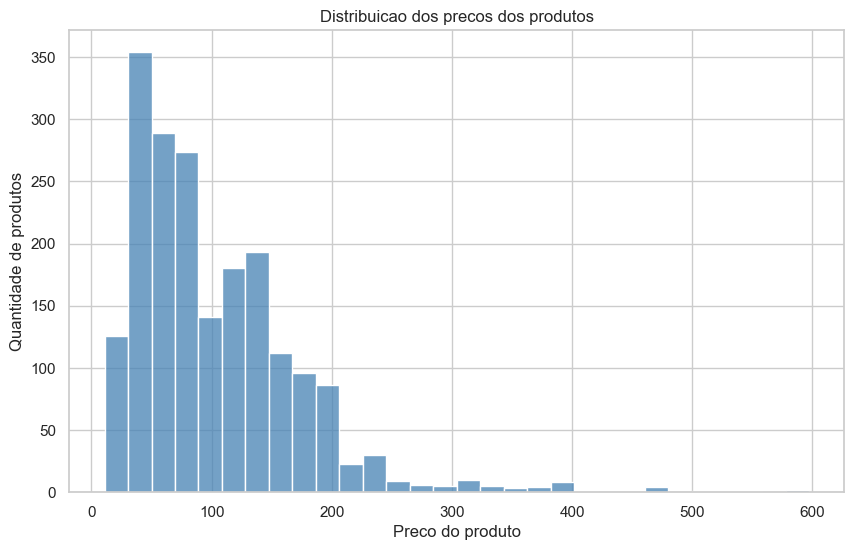

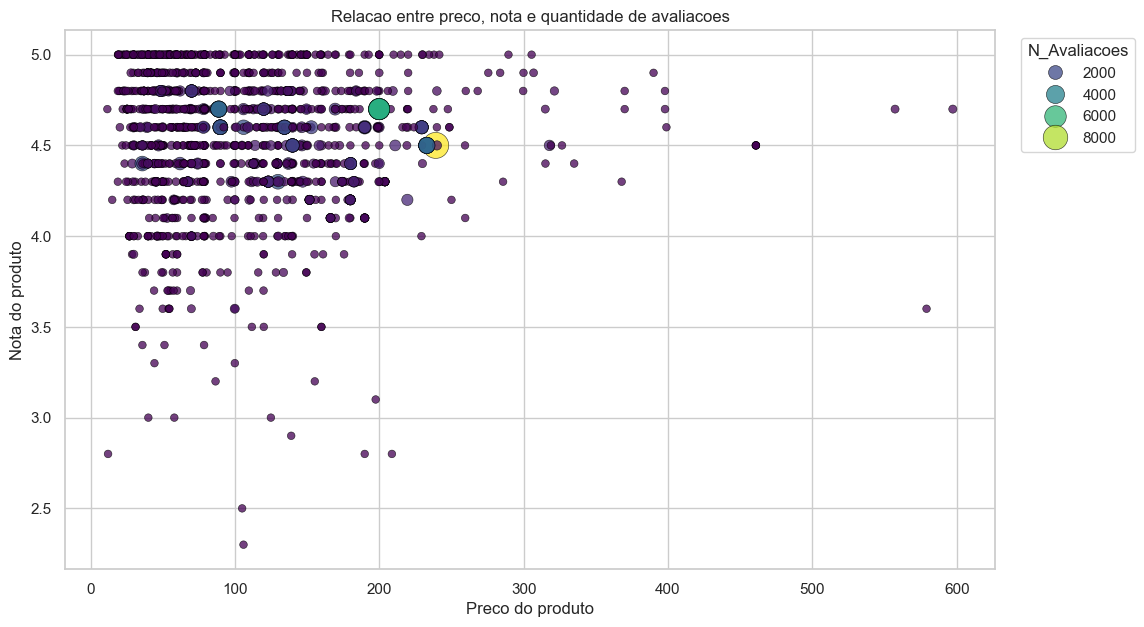

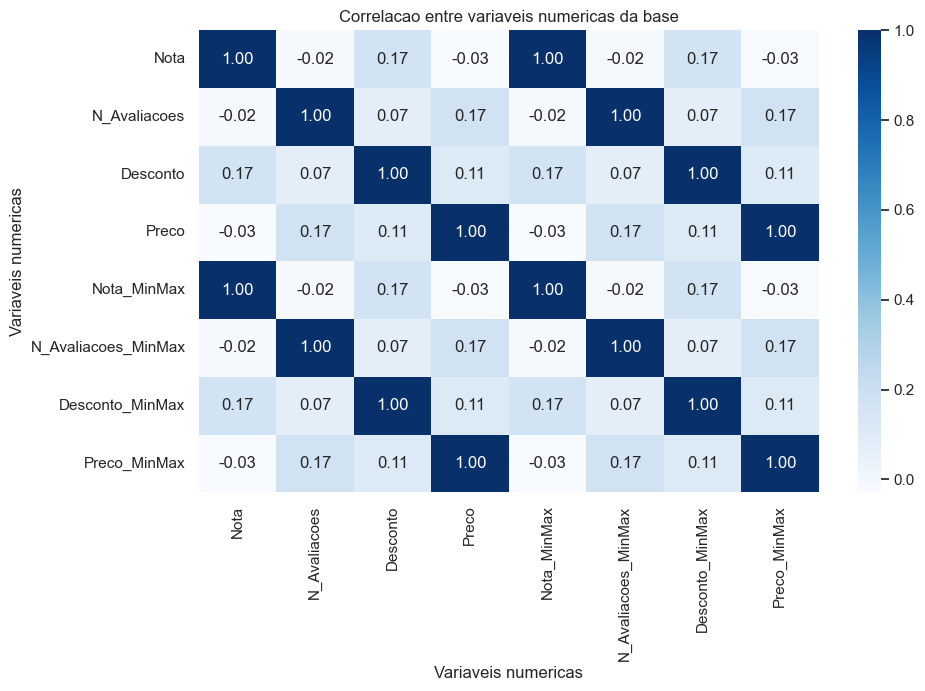

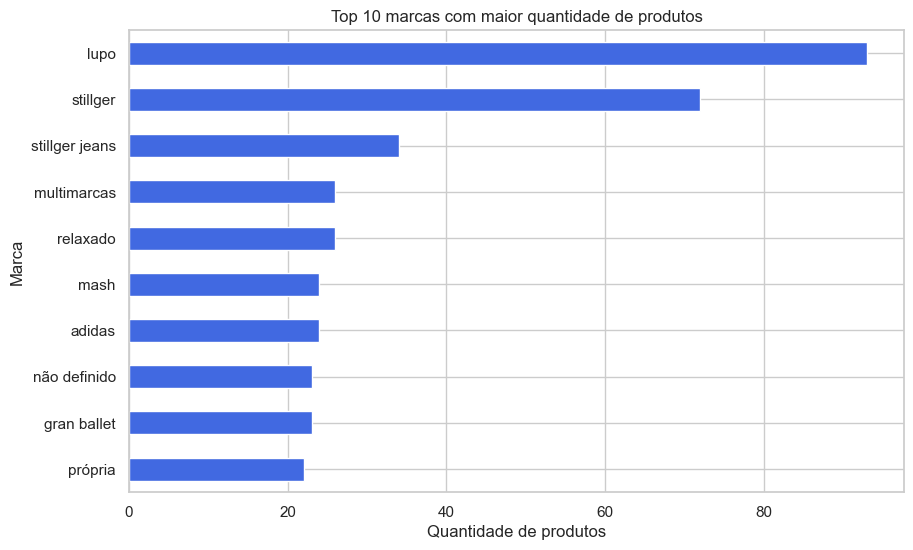

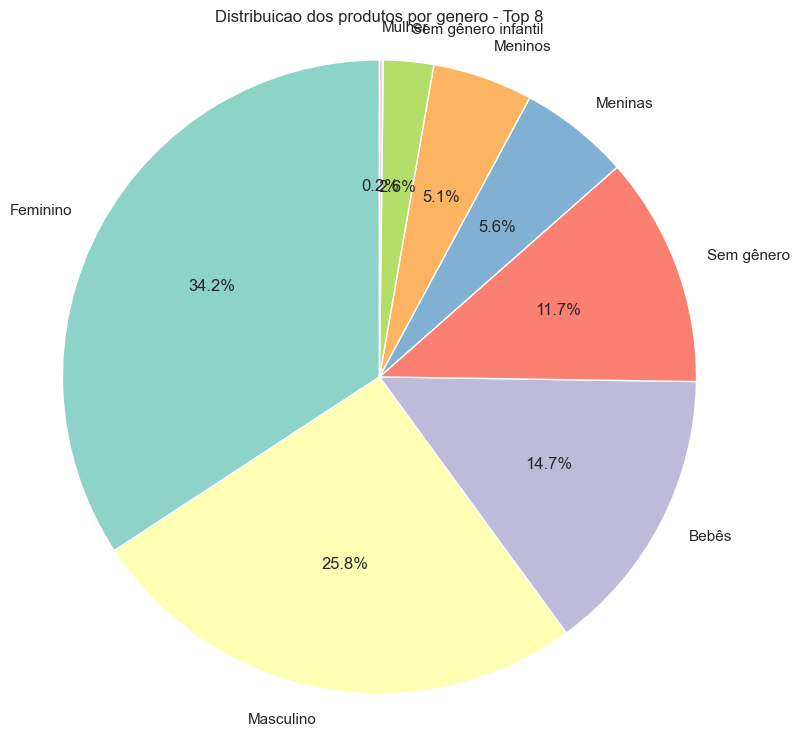

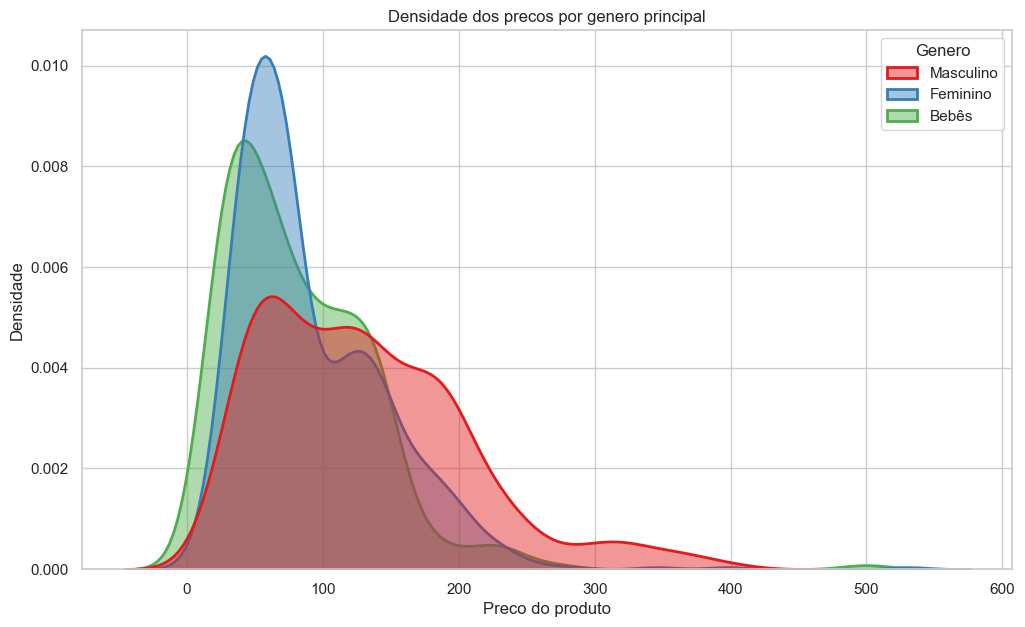

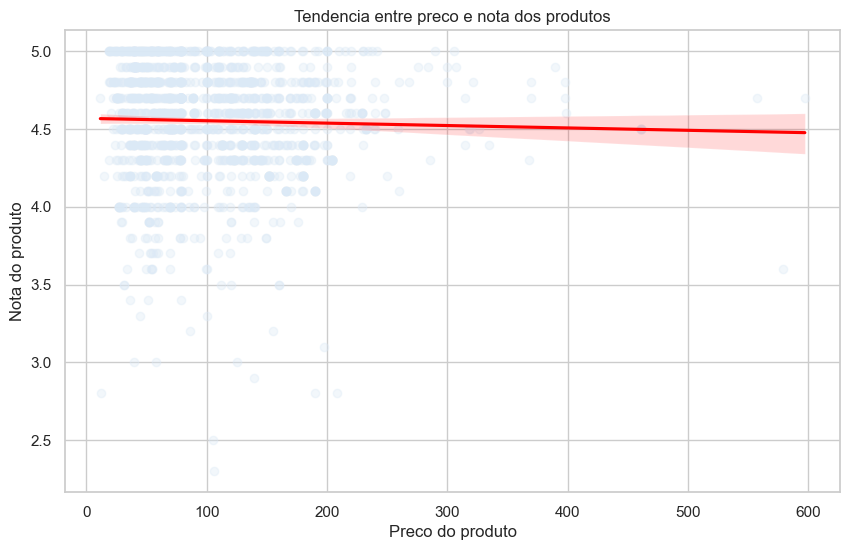

In [9]:
# Seleciona colunas numericas importantes para as visualizacoes.
colunas_numericas = [
    'Nota',
    'N_Avaliacoes',
    'Desconto',
    'Preco',
    'Nota_MinMax',
    'N_Avaliacoes_MinMax',
    'Desconto_MinMax',
    'Preco_MinMax'
]
colunas_numericas = [col for col in colunas_numericas if col in base.columns] # Garante que as colunas existam na base antes de usar.

# Cria uma base auxiliar sem valores nulos nas colunas mais usadas nos graficos.
base_graficos = base.dropna(subset=['Preco', 'Nota', 'N_Avaliacoes']).copy()
top_marcas = base['Marca'].value_counts().head(10).sort_values()
distribuicao_genero = base['Genero'].value_counts()
top8_generos = distribuicao_genero.head(8)
generos_principais = base['Genero'].value_counts().head(3).index
base_densidade = base[base['Genero'].isin(generos_principais)].dropna(subset=['Preco']).copy()

# 1) Histograma: mostra como os precos estao distribuidos na base.
plt.figure(figsize=(10, 6))
sns.histplot(data=base, x='Preco', bins=30, kde=False, color='steelblue')
plt.title('Distribuicao dos precos dos produtos')
plt.xlabel('Preco do produto')
plt.ylabel('Quantidade de produtos')
plt.show()

# 2) Grafico de dispersao: avalia a relacao entre preco e nota, destacando N_Avaliacoes por cor e tamanho.
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=base_graficos,
    x='Preco',
    y='Nota',
    hue='N_Avaliacoes',
    size='N_Avaliacoes',
    palette='viridis',
    sizes=(30, 350),
    alpha=0.75,
    edgecolor='black'
)
plt.title('Relacao entre preco, nota e quantidade de avaliacoes')
plt.xlabel('Preco do produto')
plt.ylabel('Nota do produto')
plt.legend(title='N_Avaliacoes', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

# 3) Mapa de calor: identifica correlacoes entre as variaveis numericas.
plt.figure(figsize=(10, 6))
sns.heatmap(base[colunas_numericas].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlacao entre variaveis numericas da base')
plt.xlabel('Variaveis numericas')
plt.ylabel('Variaveis numericas')
plt.show()

# 4) Grafico de barras: destaca as 10 marcas com mais produtos cadastrados.
plt.figure(figsize=(10, 6))
top_marcas.plot(kind='barh', color='royalblue')
plt.title('Top 10 marcas com maior quantidade de produtos')
plt.xlabel('Quantidade de produtos')
plt.ylabel('Marca')
plt.show()

# 5) Grafico de pizza: apresenta apenas os 8 generos mais frequentes para evitar poluicao visual.
plt.figure(figsize=(9, 9))
cores_pizza = sns.color_palette('Set3', len(top8_generos))
plt.pie(top8_generos, labels=top8_generos.index, autopct='%1.1f%%', startangle=90, colors=cores_pizza)
plt.title('Distribuicao dos produtos por genero - Top 8')
plt.ylabel('')
plt.axis('equal')
plt.show()

# 6) Grafico de densidade: compara a distribuicao de preco entre os generos mais frequentes com cores mais contrastantes.
plt.figure(figsize=(12, 7))
sns.kdeplot(data=base_densidade, x='Preco', hue='Genero', fill=True, common_norm=False, alpha=0.45, linewidth=2, palette='Set1')
plt.title('Densidade dos precos por genero principal')
plt.xlabel('Preco do produto')
plt.ylabel('Densidade')
plt.show()

# 7) Grafico de regressao: adiciona linha de tendencia para preco e nota.
plt.figure(figsize=(10, 6))
sns.regplot(data=base_graficos, x='Preco', y='Nota', scatter_kws={'alpha': 0.35}, line_kws={'color': 'red'})
plt.title('Tendencia entre preco e nota dos produtos')
plt.xlabel('Preco do produto')
plt.ylabel('Nota do produto')
plt.show()


## 3. Principais achados da analise

Com base nos graficos, alguns pontos podem ser destacados:

1. O histograma ajuda a perceber que os precos nao parecem estar distribuidos de forma uniforme. Isso pode indicar concentracao de produtos em determinadas faixas de valor.
2. O grafico de dispersao mostra como preco e nota se comportam juntos. Em muitos casos, produtos mais caros nao necessariamente recebem notas maiores, o que e uma observacao importante para negocio.
3. O mapa de calor facilita enxergar se existem correlacoes mais fortes entre preco, nota, desconto e numero de avaliacoes. Isso ajuda a decidir quais variaveis valem a pena investigar depois.
4. O grafico de barras deixa claro quais marcas dominam o cadastro de produtos, o que pode indicar maior presenca comercial ou maior volume de anuncios.
5. O grafico de pizza resume a composicao do catalogo por genero, o que e util para entender o perfil geral da base.
6. O grafico de densidade permite comparar o comportamento dos precos entre os principais generos, mostrando se algum grupo tende a concentrar produtos mais baratos ou mais caros.
7. O grafico de regressao oferece uma visao mais analitica da relacao entre preco e nota, pois alem dos pontos ele mostra a tendencia geral observada nos dados.
